# EfficientAD Algorithm 1 Training Notebook

This notebook implements Algorithm 1 from the EfficientAD paper for training a student network and autoencoder given a pre-trained teacher model.

## Section 1: Imports and Setup

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from tqdm import tqdm
import numpy as np
from pathlib import Path
from typing import Tuple, Union, Dict, Any
from PIL import Image, ImageEnhance

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Section 2: Network Architectures

In [2]:
class PDN_S(nn.Module):
    """Patch Description Network - Small (Table 6)"""
    def __init__(self, out_channels: int = 384, padding: bool = False):
        super().__init__()
        self.padding_mode = padding
        
        self.conv1 = nn.Conv2d(3, 128, kernel_size=4, stride=1, padding=3)
        self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1)
        
        self.conv2 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=3)
        self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1)
        
        self.conv3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(256, out_channels, kernel_size=4, stride=1, padding=0)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.avgpool1(x)
        x = F.relu(self.conv2(x))
        x = self.avgpool2(x)
        x = F.relu(self.conv3(x))
        x = self.conv4(x)
        return x


class AutoEncoder(nn.Module):
    """AutoEncoder (Table 8)"""
    def __init__(self, out_channels: int = 384, img_size: int = 256, padding: bool = False):
        super().__init__()
        self.out_channels = out_channels
        self.img_size = img_size
        
        # Encoder
        self.enc_conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1)
        self.enc_conv3 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv4 = nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv5 = nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv6 = nn.Conv2d(64, 64, kernel_size=8, stride=1, padding=0)
        
        # Decoder
        self.dec_conv1 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout1 = nn.Dropout(0.2)
        self.dec_conv2 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout2 = nn.Dropout(0.2)
        self.dec_conv3 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout3 = nn.Dropout(0.2)
        self.dec_conv4 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout4 = nn.Dropout(0.2)
        self.dec_conv5 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout5 = nn.Dropout(0.2)
        self.dec_conv6 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout6 = nn.Dropout(0.2)
        self.dec_conv7 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.dec_conv8 = nn.Conv2d(64, out_channels, kernel_size=3, stride=1, padding=1)
        
    def forward(self, x):
        # Encoder
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = F.relu(self.enc_conv3(x))
        x = F.relu(self.enc_conv4(x))
        x = F.relu(self.enc_conv5(x))
        x = self.enc_conv6(x)  # (B, 64, 1, 1)
        
        # Decoder with bilinear upsampling
        x = F.interpolate(x, size=(3, 3), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv1(x))
        x = self.dec_dropout1(x)
        
        x = F.interpolate(x, size=(8, 8), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv2(x))
        x = self.dec_dropout2(x)
        
        x = F.interpolate(x, size=(15, 15), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv3(x))
        x = self.dec_dropout3(x)
        
        x = F.interpolate(x, size=(32, 32), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv4(x))
        x = self.dec_dropout4(x)
        
        x = F.interpolate(x, size=(63, 63), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv5(x))
        x = self.dec_dropout5(x)
        
        x = F.interpolate(x, size=(127, 127), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv6(x))
        x = self.dec_dropout6(x)
        
        x = F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv7(x))
        x = self.dec_conv8(x)
        
        return x


print(f'Network architectures loaded successfully')

Network architectures loaded successfully


## Section 3: Data Loading Utilities

In [3]:
def build_imagenet_normalization():
    """Build ImageNet normalization transform"""
    return transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )


class NormalDataset(Dataset):
    """Dataset for normal images"""
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.img_paths = list(self.img_dir.glob('*'))
        self.img_paths = [p for p in self.img_paths if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
        
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        return img, 0 


class RandomAugment:
    """Random augmentation for brightness, contrast, saturation (Algorithm 1, lines 25-27)"""
    def __call__(self, img):
        aug_type = np.random.randint(1, 4) 
        coeff = np.random.uniform(0.8, 1.2)
        
        if aug_type == 1:  #brightness
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(coeff)
        elif aug_type == 2:  #contrast
            enhancer = ImageEnhance.Contrast(img)
            img = enhancer.enhance(coeff)
        else:  #saturation 
            enhancer = ImageEnhance.Color(img)
            img = enhancer.enhance(coeff)
        
        return img

print('Data loading utilities loaded successfully')

Data loading utilities loaded successfully


## Section 4: Configuration

In [5]:
# Configuration paths (modify this for your setup)
config = {
    'model_dir': './model_log_juice_bottle', #path for the model being made 
    'dataset_path': './mvtec_loco_anomaly_detection/juice_bottle',  #path to dataset with train/good and validation/good subdirs
    'imagenet_path': './archive/train_combined',  #path to ImageNet dataset
    'teacher_model_path': './Save_checkpoints/teacher_final.pth',  #path to pre-trained teacher
    'pdn_size': 's',
    'out_channels': 384,
    'img_size': 256,
    'device': device,
    'n_training_iterations': 70000,
    'learning_rate_initial': 1e-4,
    'learning_rate_final': 1e-5,
    'lr_decay_iteration': 66500,
    'weight_decay': 1e-5,
}

Path(config['model_dir']).mkdir(parents=True, exist_ok=True)

print('Configuration loaded:')
for key, value in config.items():
    print(f'  {key}: {value}')

Configuration loaded:
  model_dir: ./model_log_juice_bottle
  dataset_path: ./mvtec_loco_anomaly_detection/juice_bottle
  imagenet_path: ./archive/train_combined
  teacher_model_path: ./Save_checkpoints/teacher_final.pth
  pdn_size: s
  out_channels: 384
  img_size: 256
  device: cuda
  n_training_iterations: 70000
  learning_rate_initial: 0.0001
  learning_rate_final: 1e-05
  lr_decay_iteration: 66500
  weight_decay: 1e-05


## Section 5: Load Pre-trained Teacher

In [6]:
teacher = PDN_S(out_channels=config['out_channels'], padding=False).to(config['device'])


ckpt = torch.load(config['teacher_model_path'], map_location=config['device'])
teacher.load_state_dict(ckpt['teacher'])
teacher.eval()

print(f'Teacher model loaded from {config["teacher_model_path"]}')
print(f'Teacher model architecture: PDN_{config["pdn_size"].upper()}')

Teacher model loaded from ./Save_checkpoints/teacher_final.pth
Teacher model architecture: PDN_S


## Section 6: Initialize Student and Autoencoder

In [ ]:
student = PDN_S(out_channels=config['out_channels'] * 2, padding=False).to(config['device'])
autoencoder = AutoEncoder(
    out_channels=config['out_channels'],
    img_size=config['img_size'],
    padding=False
).to(config['device'])
autoencoder.train()

plist = nn.ParameterList()
plist.extend(autoencoder.parameters())
plist.extend(student.parameters())
optimizer = Adam(plist, lr=config['learning_rate_initial'], weight_decay=config['weight_decay'])
print(f'Student output channels: {config["out_channels"] * 2}')
print(f'Autoencoder output channels: {config["out_channels"]}')

Student and autoencoder networks initialized
Student output channels: 768
Autoencoder output channels: 384


## Section 7: Data Preparation

In [ ]:
# Prepare transforms
base_transform = transforms.Compose([
    transforms.Resize((config['img_size'], config['img_size'])),
    transforms.ToTensor(),
])
normalize = build_imagenet_normalization()
def train_transform(img):
    img_tensor = normalize(base_transform(img))
    img_tensor_aug = img_tensor.clone()
    
    #random augmentation
    aug_type = np.random.randint(1, 4)
    coeff = np.random.uniform(0.8, 1.2)
    
    if aug_type == 1:  #brightness
        img_tensor_aug = img_tensor_aug * coeff
    elif aug_type == 2:  #contrast
        img_tensor_aug = (img_tensor_aug - 0.5) * coeff + 0.5
    else:  #saturation
        gray = img_tensor_aug.mean(dim=0, keepdim=True)
        img_tensor_aug = gray + (img_tensor_aug - gray) * coeff
    
    return img_tensor, torch.clamp(img_tensor_aug, 0, 1)


def valid_transform(img):
    return normalize(base_transform(img))

train_img_dir = os.path.join(config['dataset_path'], 'train', 'good')
valid_img_dir = os.path.join(config['dataset_path'], 'validation', 'good')

if os.path.exists(valid_img_dir):
    train_dataset = NormalDataset(train_img_dir, train_transform)
    valid_dataset = NormalDataset(valid_img_dir, valid_transform)
    print(f'Loaded train dataset from {train_img_dir} ({len(train_dataset)} images)')
    print(f'Loaded validation dataset from {valid_img_dir} ({len(valid_dataset)} images)')


train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=1, shuffle=False)

# Load ImageNet dataset
imagenet_dataset = torchvision.datasets.ImageFolder(
    root=config['imagenet_path'],
    transform=transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomGrayscale(p=0.3),
        transforms.CenterCrop((config['img_size'], config['img_size'])),
        transforms.ToTensor(),
        build_imagenet_normalization(),
    ])
)
imagenet_dataloader = DataLoader(imagenet_dataset, batch_size=1, shuffle=True)
print(f'Loaded ImageNet dataset ({len(imagenet_dataset)} images)')


Loaded train dataset from ./mvtec_loco_anomaly_detection/juice_bottle/train/good (335 images)
Loaded validation dataset from ./mvtec_loco_anomaly_detection/juice_bottle/validation/good (54 images)
Loaded ImageNet dataset (130000 images)


## Section 8: Compute Teacher Normalization Parameters (Algorithm 1, lines 3-10)

In [ ]:
# Compute mu and sigma for teacher output normalization
print('Computing teacher normalization parameters (mu and sigma)...')
with torch.no_grad():
    teacher_outputs = []
    for i in tqdm(range(len(train_dataset)), desc='Calculating mean and std for train dataset'):
        data = train_dataset[i]
        if isinstance(data[0], tuple):
            img_train = data[0][0]
        else:
            img_train = data[0]
        
        img_train = img_train.unsqueeze(0).to(config['device'])
        teacher_output = teacher(img_train).squeeze()
        teacher_outputs.append(teacher_output.cpu())
    
    stacked_teacher_outputs = torch.stack(teacher_outputs, dim=0)
    mu = stacked_teacher_outputs.mean(dim=(0, 2, 3))
    sigma = stacked_teacher_outputs.std(dim=(0, 2, 3))
print(f'mu shape: {mu.shape}')
print(f'sigma shape: {sigma.shape}')
print(f'mu mean: {mu.mean():.6f}, max: {mu.max():.6f}, min: {mu.min():.6f}')
print(f'sigma mean: {sigma.mean():.6f}, max: {sigma.max():.6f}, min: {sigma.min():.6f}')


Computing teacher normalization parameters (mu and sigma)...


Calculating mean and std for train dataset: 100%|██████████| 335/335 [00:13<00:00, 24.91it/s]


mu shape: torch.Size([384])
sigma shape: torch.Size([384])
mu mean: -0.086278, max: 1.051969, min: -0.944470
sigma mean: 0.466582, max: 1.002795, min: 0.205007


# Section 8.5 Loss tracking

In [ ]:
## Section 8.5: Initialize Loss Tracking
print('Initializing loss tracking...')
loss_history = {
    'total': [],
    'student': [], 
    'ae': [],
    'student_ae': [],
    'iteration': []
}

Initializing loss tracking...
Loss tracking initialized:
  - Tracking: Total, Student, AE, Student-AE losses
  - Will save plots and CSV after training


## Section 9: Main Training Loop (Algorithm 1, lines 12-42)

In [ ]:
mu = mu.to(config['device'])
sigma = sigma.to(config['device'])
teacher_output_normalization = transforms.Normalize(mu, sigma)
imagenet_dataloader_iter = iter(imagenet_dataloader)
train_dataloader_iter = iter(train_dataloader)
print('Starting training with loss tracking...')
with tqdm(range(config['n_training_iterations']), desc='Training student network and autoencoder') as pbar:
    for it in pbar:
        try:
            batch = next(train_dataloader_iter)
        except StopIteration:
            train_dataloader_iter = iter(train_dataloader)
            batch = next(train_dataloader_iter)
        
        img_train = batch[0][0].to(config['device']) 
        img_aug = batch[0][1].to(config['device'])  
        
        with torch.no_grad():
            teacher_output = teacher(img_train)
            normalized_teacher_output = teacher_output_normalization(teacher_output)
        
        student_output = student(img_train)
        student_output_st = student_output[:, :config['out_channels'], :, :]
        diff_teacher_student = (normalized_teacher_output - student_output_st) ** 2
        
        threshold = torch.quantile(input=diff_teacher_student, q=0.999)
        loss_hard = torch.mean(diff_teacher_student[torch.where(diff_teacher_student >= threshold)])
        
        try:
            imagenet_batch = next(imagenet_dataloader_iter)
        except StopIteration:
            imagenet_dataloader_iter = iter(imagenet_dataloader)
            imagenet_batch = next(imagenet_dataloader_iter)
        
        imagenet_img = imagenet_batch[0].to(config['device'])
        loss_student = loss_hard + torch.mean(student(imagenet_img)[:, :config['out_channels'], :, :] ** 2)
        
        # Autoencoder loss (Algorithm 1, lines 29-37)
        autoencoder_output = autoencoder(img_aug)
        with torch.no_grad():
            teacher_output = teacher(img_aug)
            normalized_teacher_output = teacher_output_normalization(teacher_output)
        
        student_output = student(img_aug)
        student_output_ae = student_output[:, config['out_channels']:, :, :]
        
        diff_teacher_ae = (normalized_teacher_output - autoencoder_output) ** 2
        diff_student_ae = (autoencoder_output - student_output_ae) ** 2
        
        loss_ae = torch.mean(diff_teacher_ae)
        loss_student_ae = torch.mean(diff_student_ae)

        loss_total = loss_student + loss_ae + loss_student_ae
        
        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()
        
    #loging losses
        if it % 100 == 0: #after 100 iters logs in .csv, can change it to preferred val
            loss_history['total'].append(loss_total.item())
            loss_history['student'].append(loss_student.item())
            loss_history['ae'].append(loss_ae.item())
            loss_history['student_ae'].append(loss_student_ae.item())
            loss_history['iteration'].append(it)
        
        if it == config['lr_decay_iteration']:
            for param_group in optimizer.param_groups:
                param_group['lr'] = config['learning_rate_final']
            print(f'\nLearning rate decayed to {config["learning_rate_final"]}')
        
        pbar.set_postfix(
            total_loss=loss_total.item(),
            student_loss=loss_student.item(),
            ae_loss=loss_ae.item()
        )

print('Training completed!')

Starting training with loss tracking...


Training student network and autoencoder:  95%|█████████▌| 66503/70000 [1:37:18<05:03, 11.51it/s, ae_loss=0.128, student_loss=0.822, total_loss=0.985] 


Learning rate decayed to 1e-05


Training student network and autoencoder: 100%|██████████| 70000/70000 [1:42:25<00:00, 11.39it/s, ae_loss=0.0884, student_loss=0.67, total_loss=0.777] 

Training completed!


Plotting training loss history...


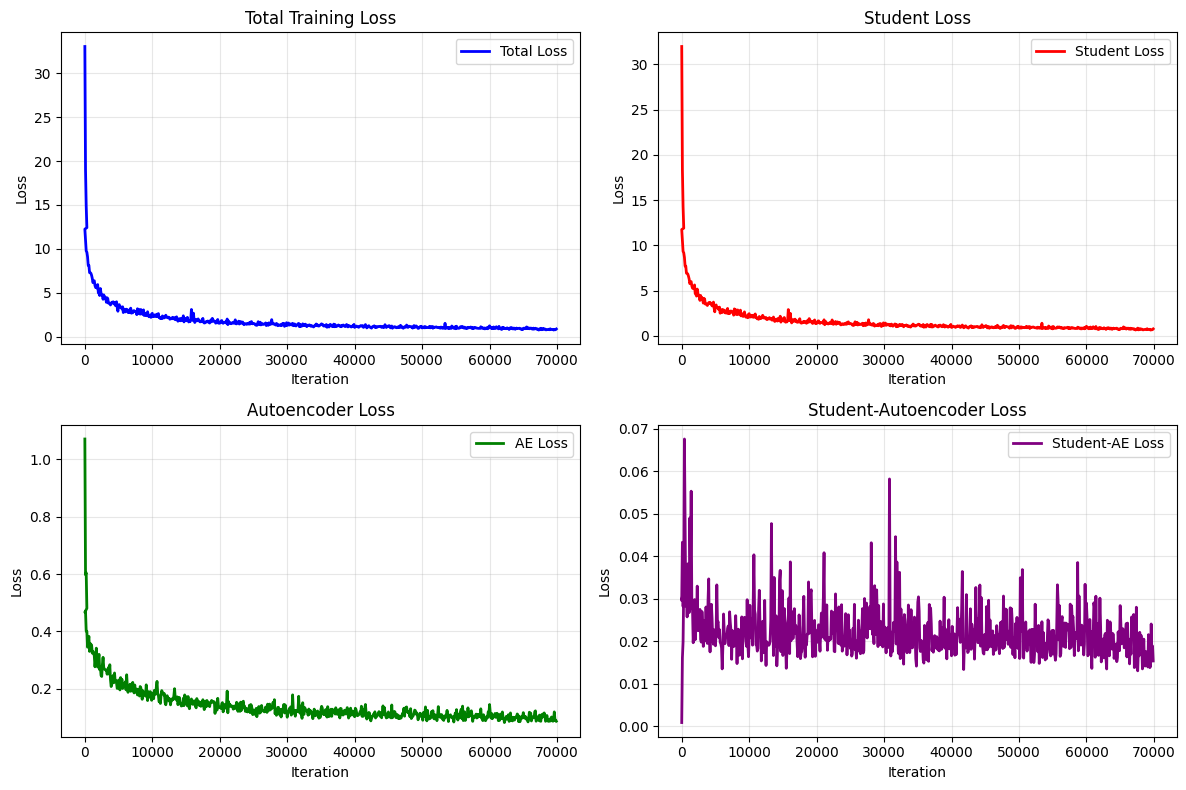

Loss plot saved to: ./model_log_juice_bottle/training_losses.png
Loss history saved to CSV file


In [ ]:
## Section 9.5: Plot Training Losses

print('Plotting training loss history...')
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(loss_history['iteration'], loss_history['total'], 'b-', linewidth=2, label='Total Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Total Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 2)
plt.plot(loss_history['iteration'], loss_history['student'], 'r-', linewidth=2, label='Student Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Student Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 3)
plt.plot(loss_history['iteration'], loss_history['ae'], 'g-', linewidth=2, label='AE Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Autoencoder Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 4)
plt.plot(loss_history['iteration'], loss_history['student_ae'], 'purple', linewidth=2, label='Student-AE Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Student-Autoencoder Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{config["model_dir"]}/training_losses.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Loss plot saved to: {config["model_dir"]}/training_losses.png')
import pandas as pd
loss_df = pd.DataFrame(loss_history)
loss_df.to_csv(f'{config["model_dir"]}/loss_history.csv', index=False)
print('Loss history saved to CSV file')

## Section 10: Validation and Quantile Computation (Algorithm 1, lines 44-57)

In [ ]:
# Compute quantiles on validation set
student_maps = []
ae_maps = []

student.eval()
autoencoder.eval()

print('Computing quantiles on validation set...')
with torch.no_grad():
    with tqdm(valid_dataloader, desc='Calculating parameters') as pbar:
        for batch in pbar:
            
            img_val = batch[0].to(config['device'])
            
            teacher_output = teacher(img_val)
            student_output = student(img_val)
            autoencoder_output = autoencoder(img_val)
            
            normalized_teacher_output = teacher_output_normalization(teacher_output)
            student_output_st = student_output[:, :config['out_channels'], :, :]
            student_output_ae = student_output[:, config['out_channels']:, :, :]
            
            diff_teacher_student = (normalized_teacher_output - student_output_st) ** 2
            diff_student_ae = (autoencoder_output - student_output_ae) ** 2
            
            student_map = torch.mean(diff_teacher_student, dim=1, keepdim=True)
            ae_map = torch.mean(diff_student_ae, dim=1, keepdim=True)
            
            resized_student_map = F.interpolate(student_map, size=(config['img_size'], config['img_size']), mode='bilinear')
            resized_ae_map = F.interpolate(ae_map, size=(config['img_size'], config['img_size']), mode='bilinear')
            
            resized_student_map = resized_student_map.squeeze().cpu()
            resized_ae_map = resized_ae_map.squeeze().cpu()
            
            student_maps.append(resized_student_map)
            ae_maps.append(resized_ae_map)

stacked_student_maps = torch.stack(student_maps, dim=0)
stacked_ae_maps = torch.stack(ae_maps, dim=0)

q_a_student = torch.quantile(input=stacked_student_maps, q=0.9)
q_b_student = torch.quantile(input=stacked_student_maps, q=0.995)
q_a_autoencoder = torch.quantile(input=stacked_ae_maps, q=0.9)
q_b_autoencoder = torch.quantile(input=stacked_ae_maps, q=0.995)

print(f'\nQuantiles computed:')
print(f'  Student 0.9 quantile: {q_a_student:.6f}')
print(f'  Student 0.995 quantile: {q_b_student:.6f}')
print(f'  Autoencoder 0.9 quantile: {q_a_autoencoder:.6f}')
print(f'  Autoencoder 0.995 quantile: {q_b_autoencoder:.6f}')


Computing quantiles on validation set...


Calculating parameters: 100%|██████████| 54/54 [00:02<00:00, 23.16it/s]



Quantiles computed:
  Student 0.9 quantile: 0.106632
  Student 0.995 quantile: 0.168163
  Autoencoder 0.9 quantile: 2.375748
  Autoencoder 0.995 quantile: 5.797678


## Section 11: Save Models and Parameters

In [15]:
# Save trained models
torch.save(student.state_dict(), os.path.join(config['model_dir'], 'student.pt'))
torch.save(autoencoder.state_dict(), os.path.join(config['model_dir'], 'autoencoder.pt'))
torch.save(mu, os.path.join(config['model_dir'], 'mu.pt'))
torch.save(sigma, os.path.join(config['model_dir'], 'sigma.pt'))

quantile_dict = {
    'q_a_student': q_a_student,
    'q_b_student': q_b_student,
    'q_a_autoencoder': q_a_autoencoder,
    'q_b_autoencoder': q_b_autoencoder,
}
torch.save(quantile_dict, os.path.join(config['model_dir'], 'quantile.pt'))

print('Models and parameters saved:')
print(f'  Student model: {os.path.join(config["model_dir"], "student.pt")}')
print(f'  Autoencoder model: {os.path.join(config["model_dir"], "autoencoder.pt")}')
print(f'  Normalization parameters: {os.path.join(config["model_dir"], "mu.pt")}, {os.path.join(config["model_dir"], "sigma.pt")}')
print(f'  Quantile parameters: {os.path.join(config["model_dir"], "quantile.pt")}')

Models and parameters saved:
  Student model: ./model_log_juice_bottle/student.pt
  Autoencoder model: ./model_log_juice_bottle/autoencoder.pt
  Normalization parameters: ./model_log_juice_bottle/mu.pt, ./model_log_juice_bottle/sigma.pt
  Quantile parameters: ./model_log_juice_bottle/quantile.pt


## Section 12: Training Summary

In [16]:
print('\n' + '='*60)
print('TRAINING COMPLETED SUCCESSFULLY')
print('='*60)
print(f'\nTraining Configuration:')
print(f'  Network Size: PDN_{config["pdn_size"].upper()}')
print(f'  Output Channels: {config["out_channels"]}')
print(f'  Image Size: {config["img_size"]}x{config["img_size"]}')
print(f'  Training Iterations: {config["n_training_iterations"]}')
print(f'  Learning Rate: {config["learning_rate_initial"]} → {config["learning_rate_final"]} (at iter {config["lr_decay_iteration"]})')
print(f'\nDatasets:')
print(f'  Train Images: {len(train_dataset)}')
print(f'  Validation Images: {len(valid_dataset)}')
print(f'  ImageNet Images: {len(imagenet_dataset)}')
print(f'\nSaved Models:')
print(f'  Location: {config["model_dir"]}')
print(f'  Files: student.pt, autoencoder.pt, mu.pt, sigma.pt, quantile.pt')
print(f'\nNext Steps:')
print(f'  Use these trained models for inference (Algorithm 2)')
print(f'  Load models: teacher, student, autoencoder')
print(f'  Load parameters: mu, sigma, quantile')
print('='*60)


TRAINING COMPLETED SUCCESSFULLY

Training Configuration:
  Network Size: PDN_S
  Output Channels: 384
  Image Size: 256x256
  Training Iterations: 70000
  Learning Rate: 0.0001 → 1e-05 (at iter 66500)

Datasets:
  Train Images: 335
  Validation Images: 54
  ImageNet Images: 130000

Saved Models:
  Location: ./model_log_juice_bottle
  Files: student.pt, autoencoder.pt, mu.pt, sigma.pt, quantile.pt

Next Steps:
  Use these trained models for inference (Algorithm 2)
  Load models: teacher, student, autoencoder
  Load parameters: mu, sigma, quantile
